# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1405]:
# Installing the libraries with the specified version
#!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [1406]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

# **Data Overview**

In [1407]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report


#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# **Exploratory Data Analysis**

In [1408]:
#Load data sets
Data = pd.read_csv('Train.csv')
DataTest = pd.read_csv('Test.csv')

In [1409]:
# Let's view the first 5 rows of the data
Data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [1410]:
# Checking the number of rows and columns in the data
Data.shape

(20000, 41)

In [1411]:
# Let's check the datatypes of the columns in the dataset
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

In [1412]:
# Let's check for duplicate values in the data
Data.duplicated().sum()

np.int64(0)

In [1413]:
# Let's check for missing values in the data
round(Data.isnull().sum() / Data.isnull().count() * 100, 2)

V1        0.09
V2        0.09
V3        0.00
V4        0.00
V5        0.00
V6        0.00
V7        0.00
V8        0.00
V9        0.00
V10       0.00
V11       0.00
V12       0.00
V13       0.00
V14       0.00
V15       0.00
V16       0.00
V17       0.00
V18       0.00
V19       0.00
V20       0.00
V21       0.00
V22       0.00
V23       0.00
V24       0.00
V25       0.00
V26       0.00
V27       0.00
V28       0.00
V29       0.00
V30       0.00
V31       0.00
V32       0.00
V33       0.00
V34       0.00
V35       0.00
V36       0.00
V37       0.00
V38       0.00
V39       0.00
V40       0.00
Target    0.00
dtype: float64

In [1414]:
# See how many values exist in the data for pass / fail in the training data
Data["Target"].value_counts()

Target
0    18890
1     1110
Name: count, dtype: int64

In [1415]:
# See how many values exist in the data for pass / fail in the test data
DataTest["Target"].value_counts(1)

Target
0    0.9436
1    0.0564
Name: proportion, dtype: float64

In [1416]:
# Let's view the statistical summary of the numerical columns in the data
Data.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


In [1417]:
# Function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [1418]:
# Function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

## Univariate analysis

* The data from each sensor follows a normal distribution curve with outliers.
* I decided not to address outliers because of the high number of features (40).  Outlier sensor data from one sensor can get cancelled out by valid data from the others.

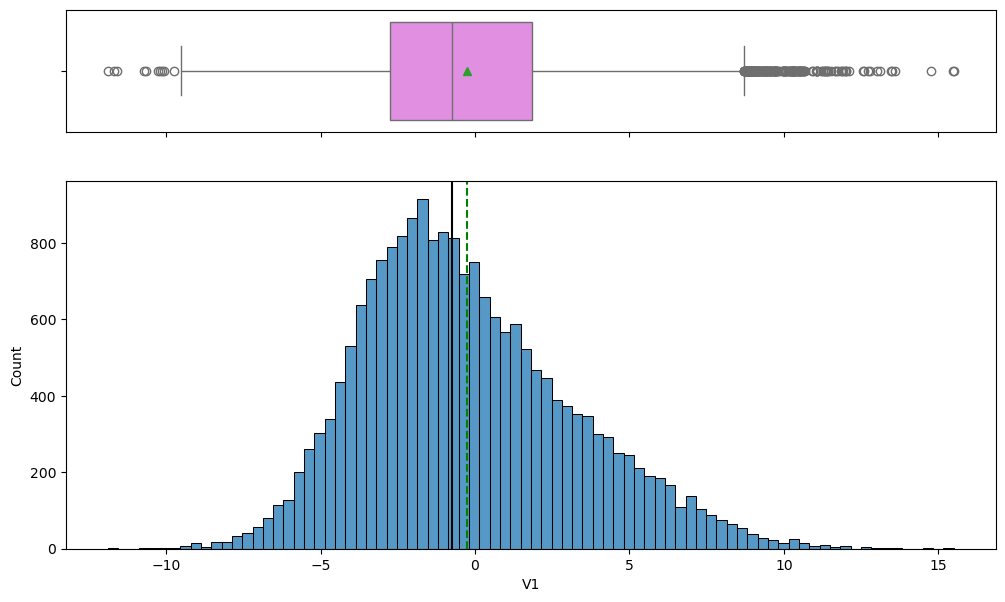

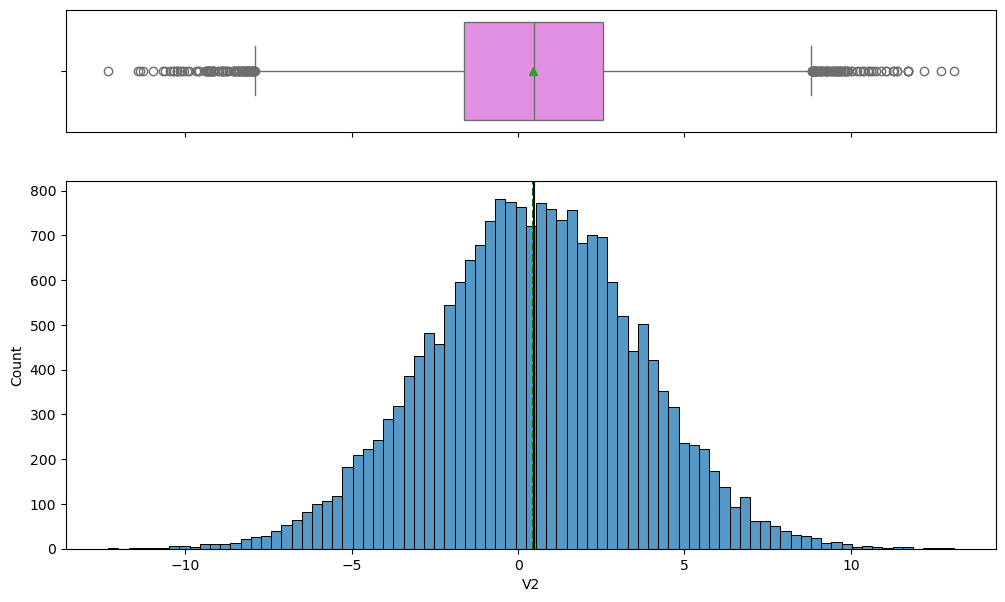

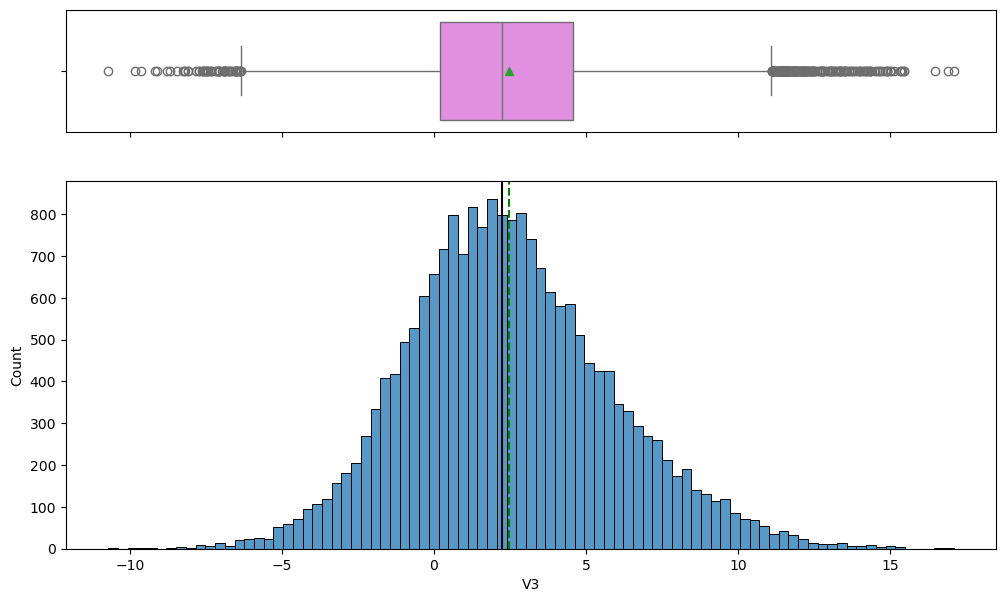

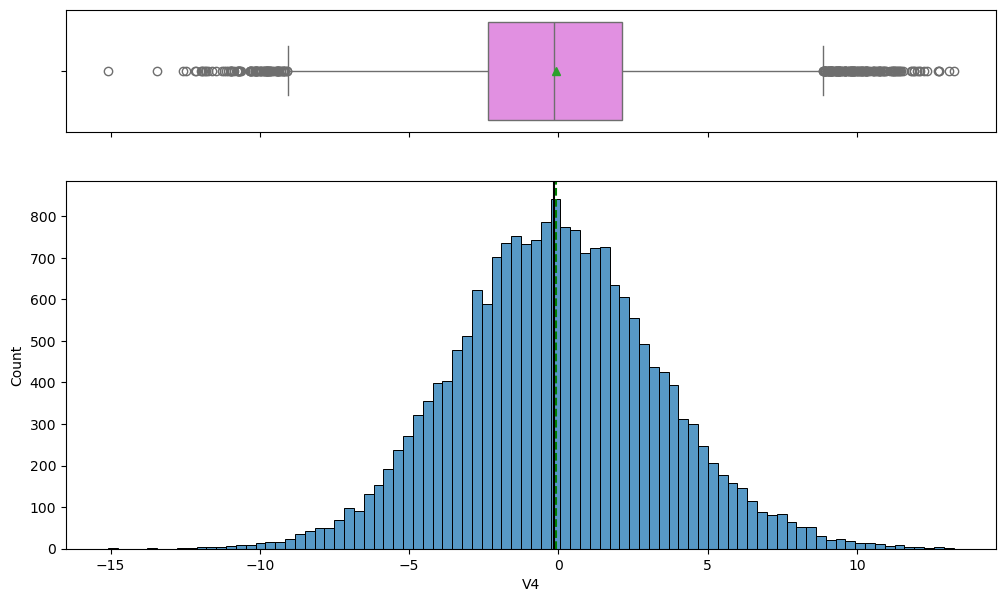

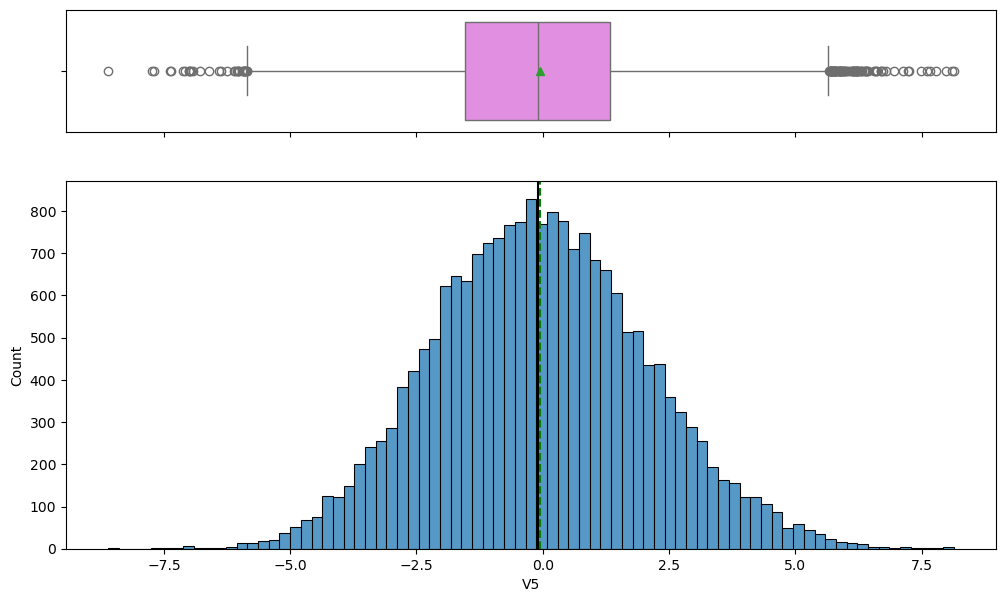

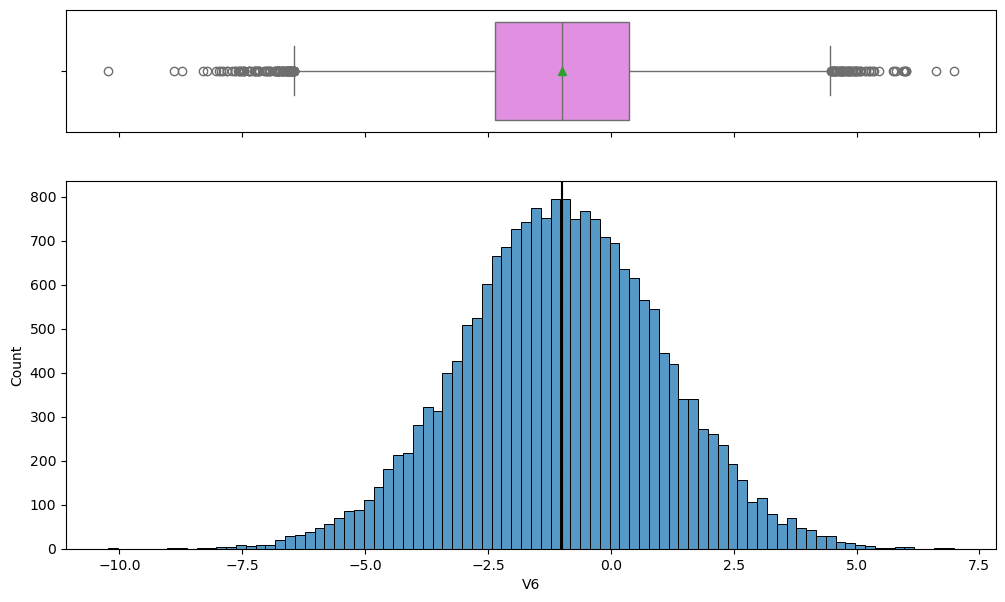

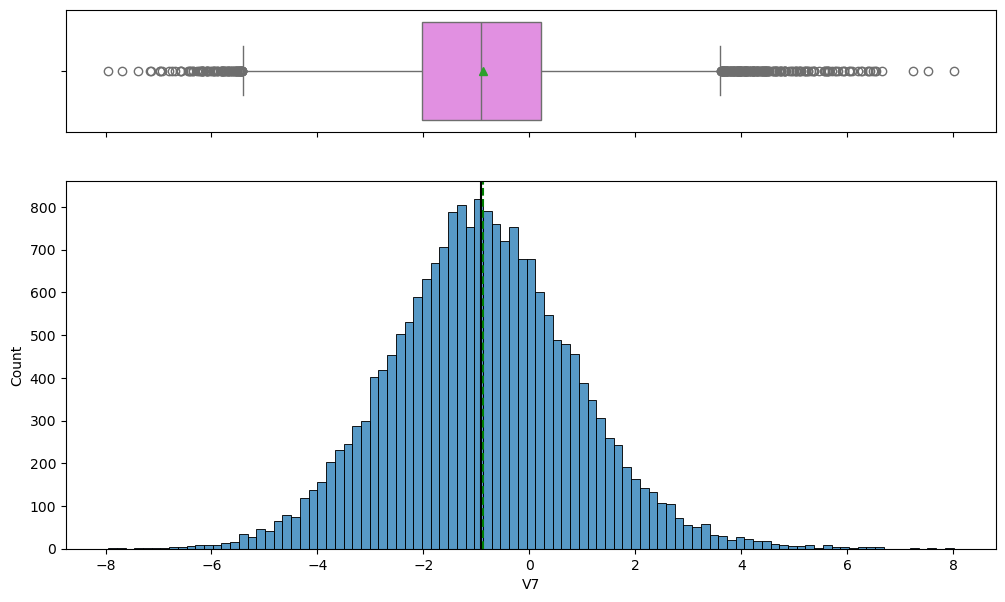

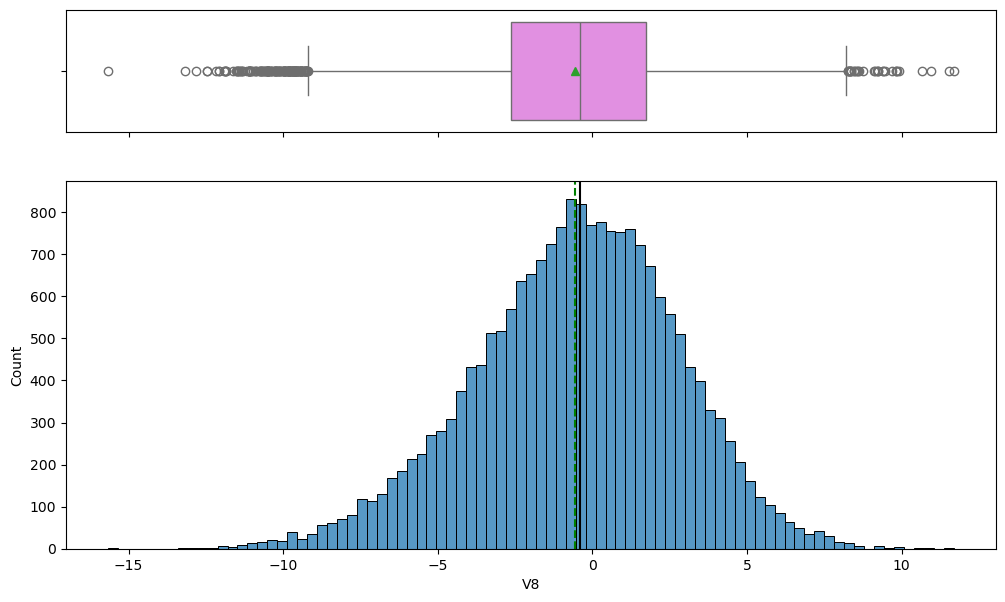

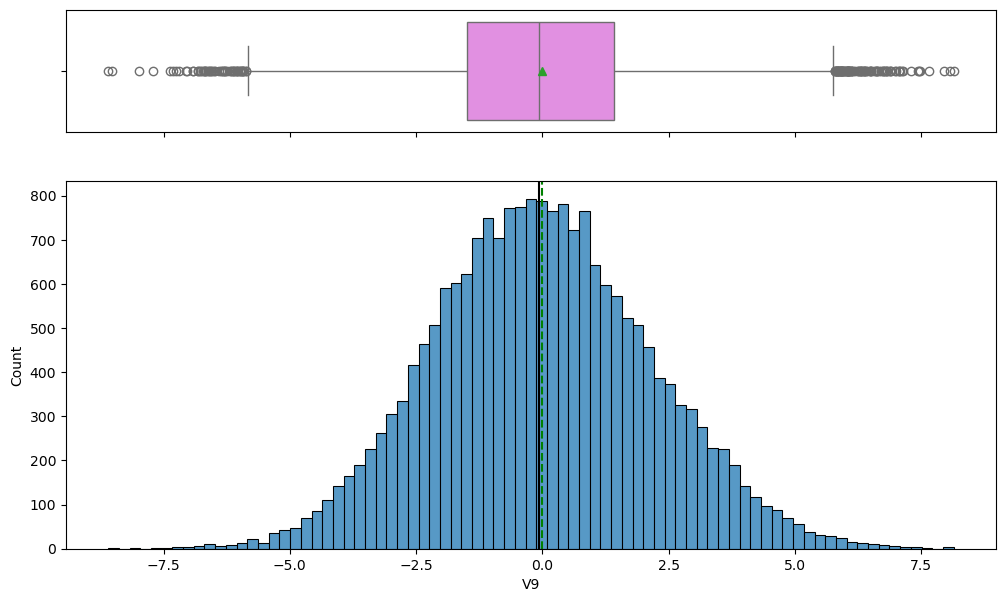

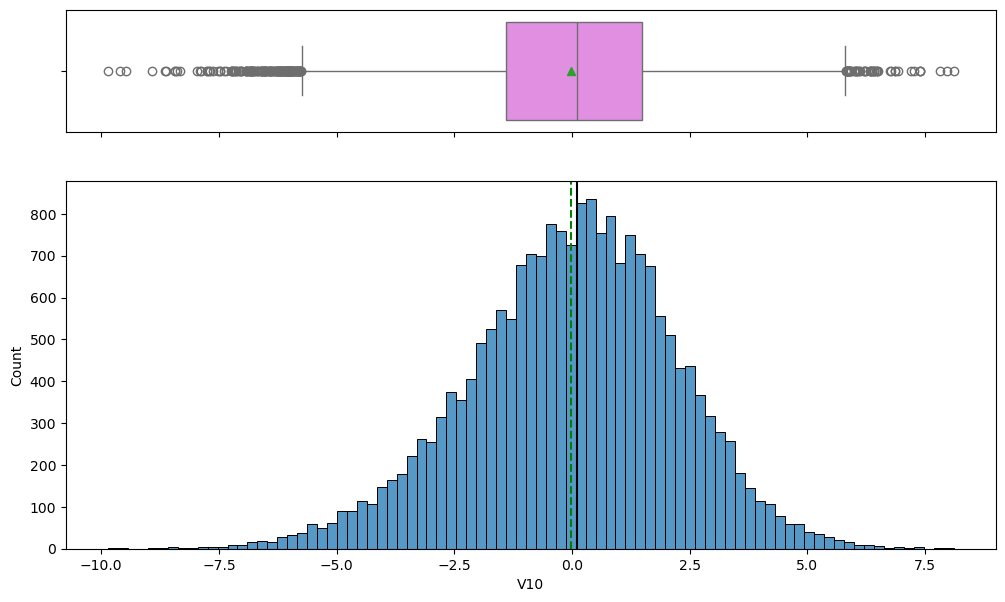

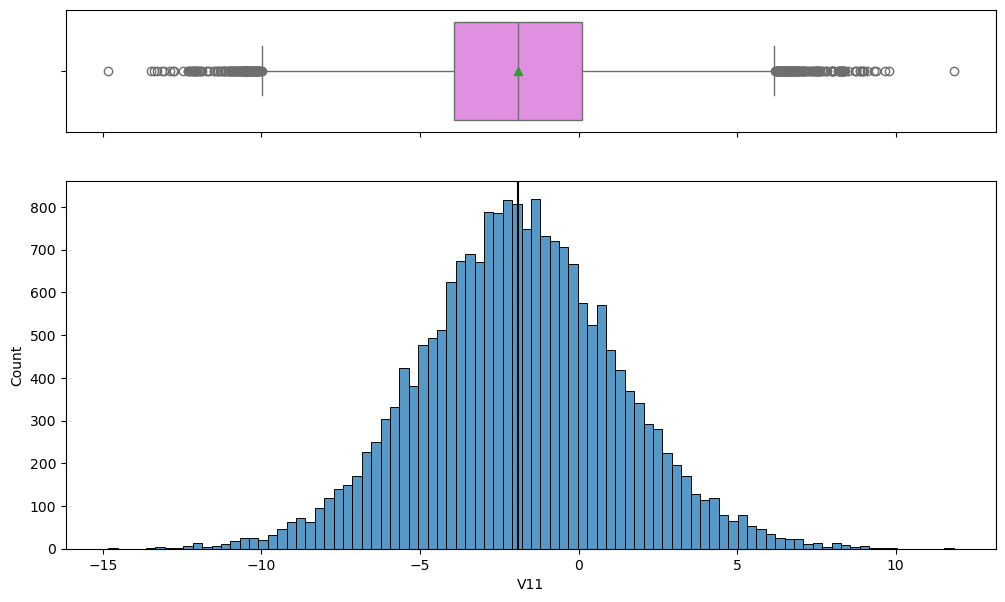

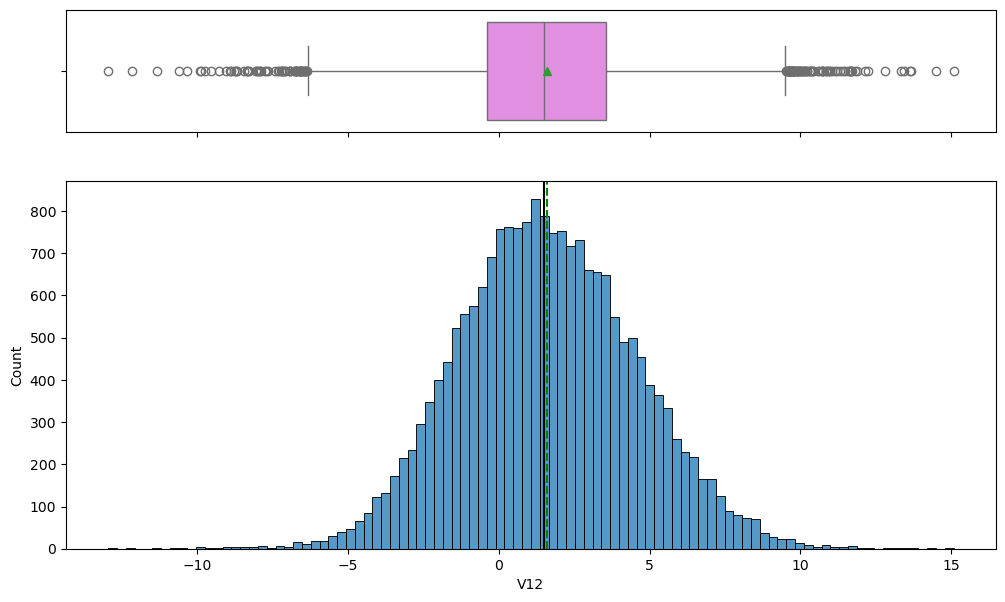

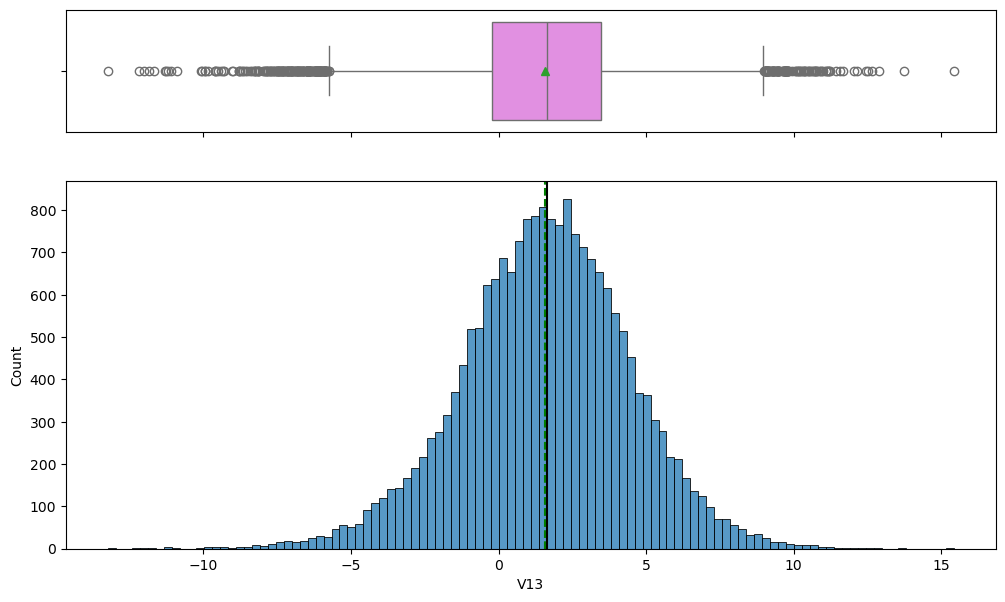

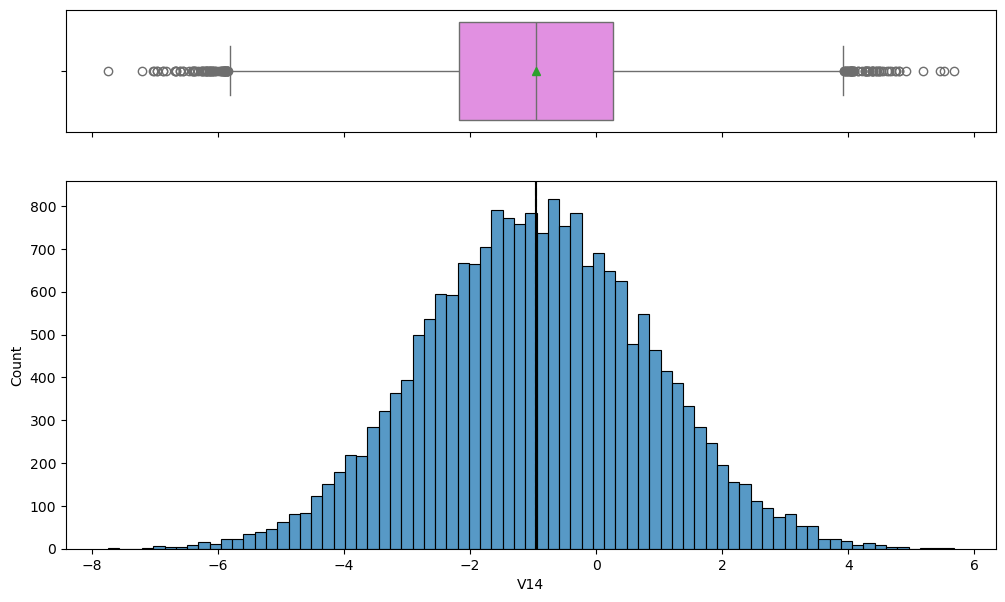

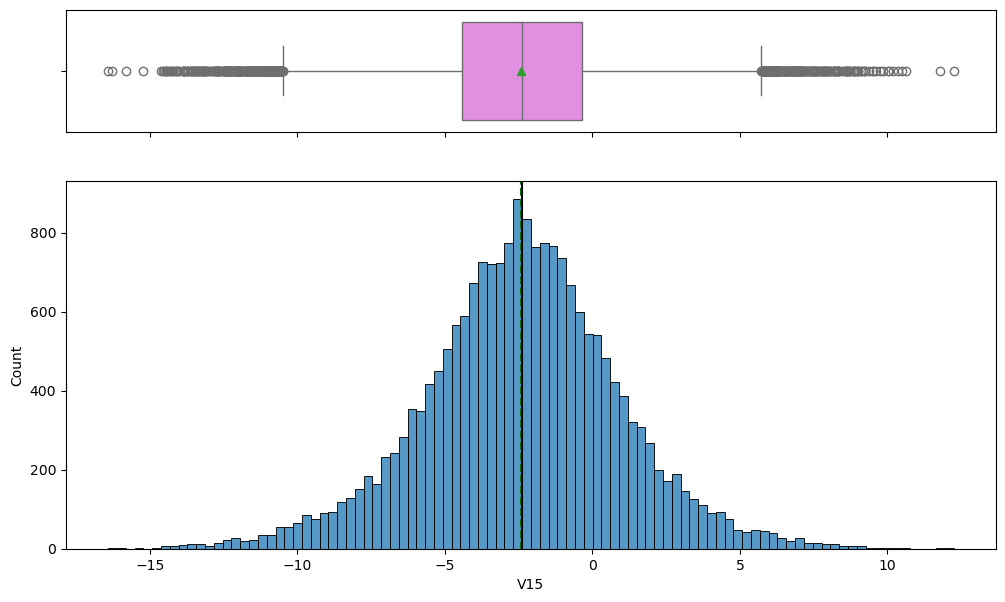

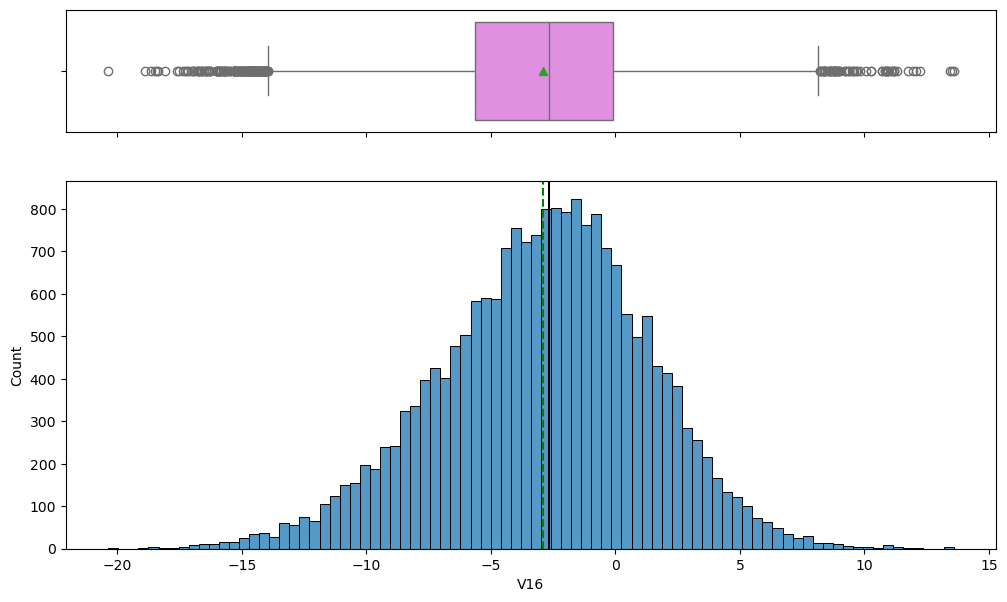

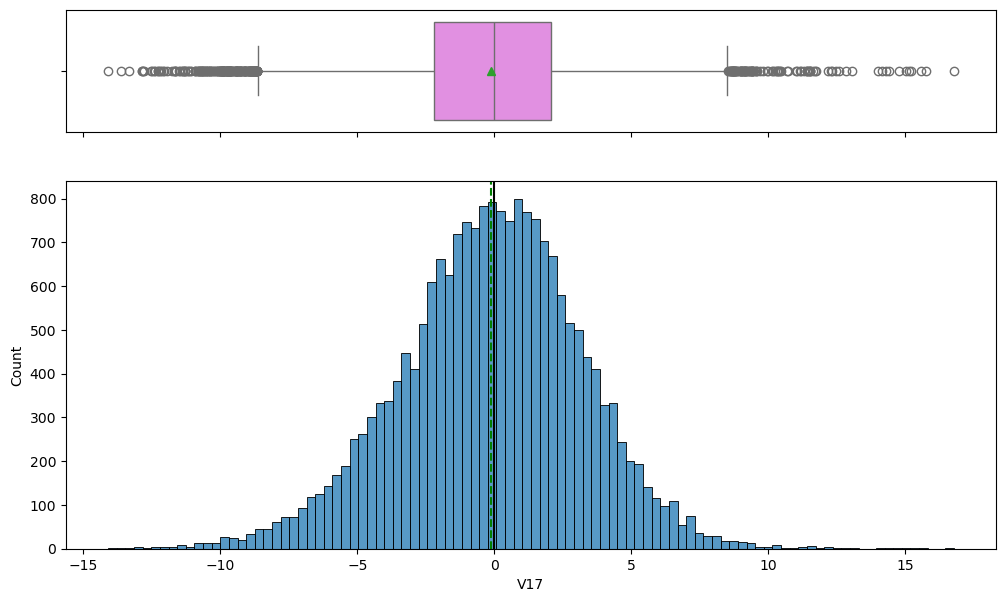

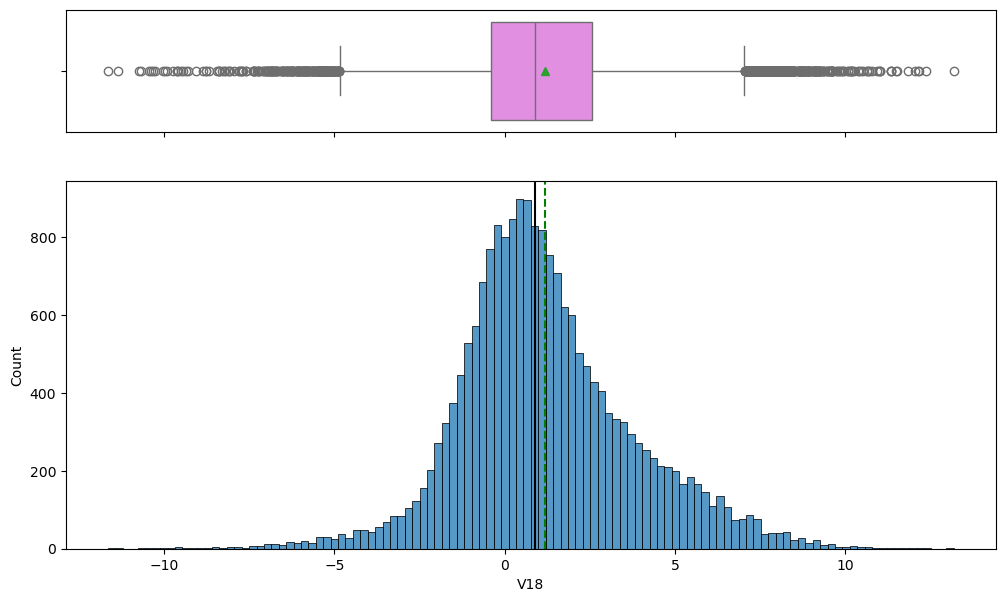

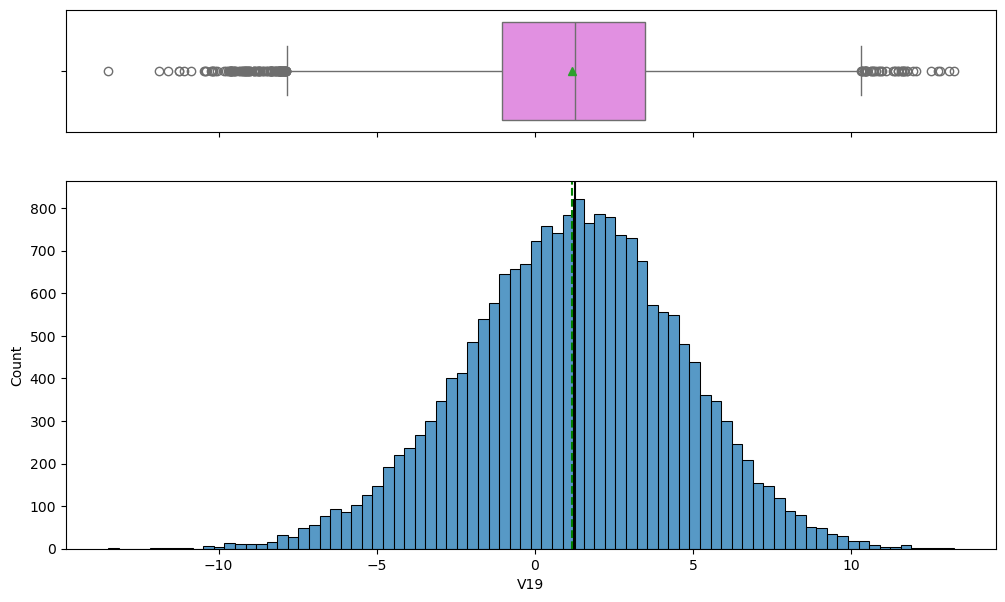

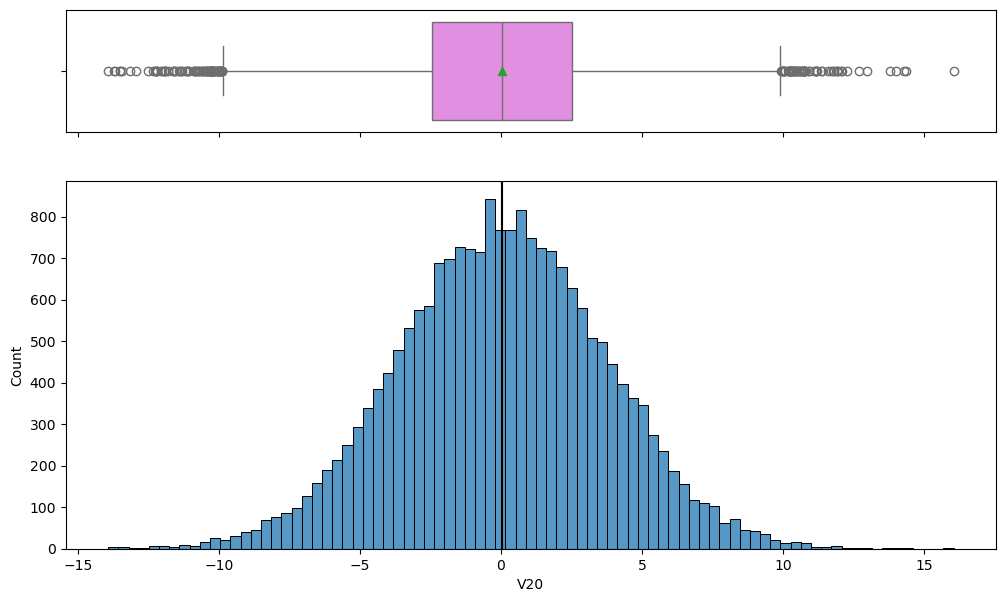

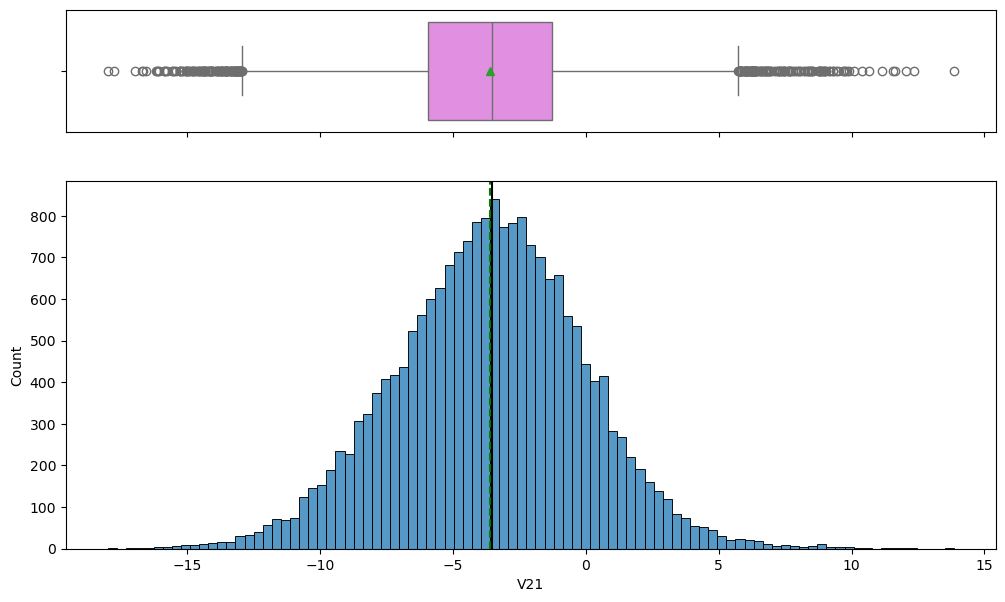

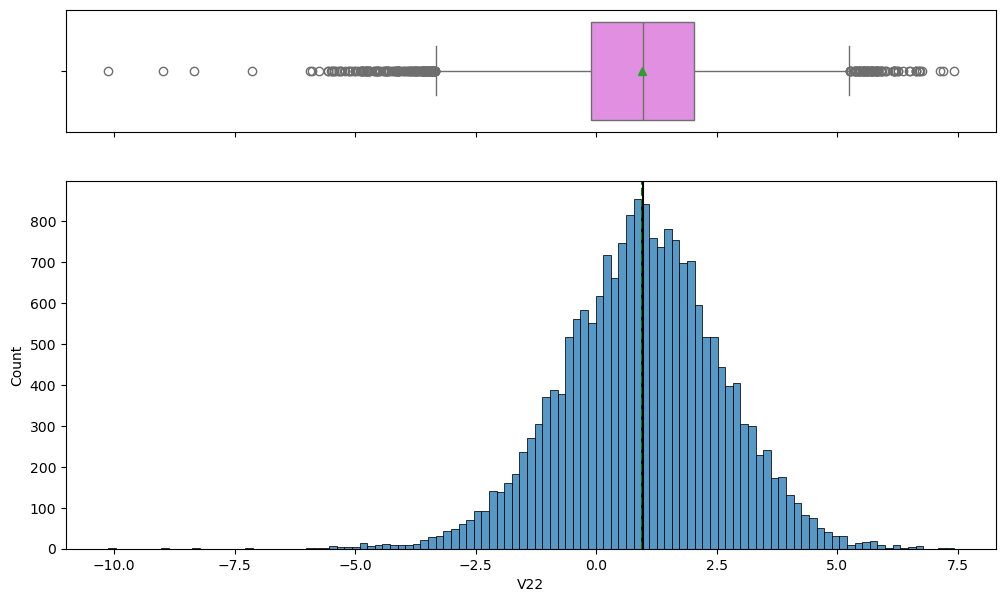

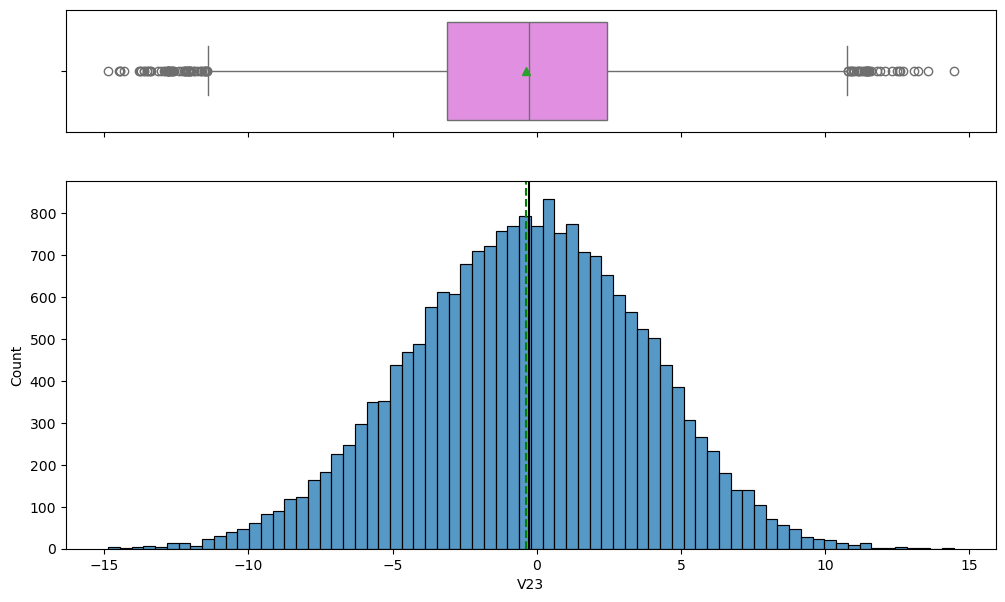

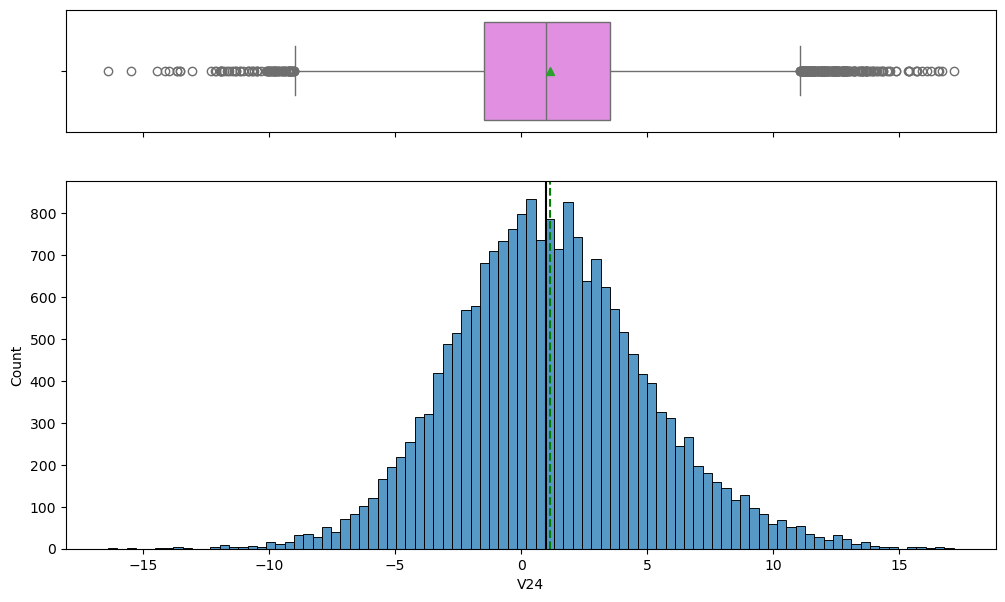

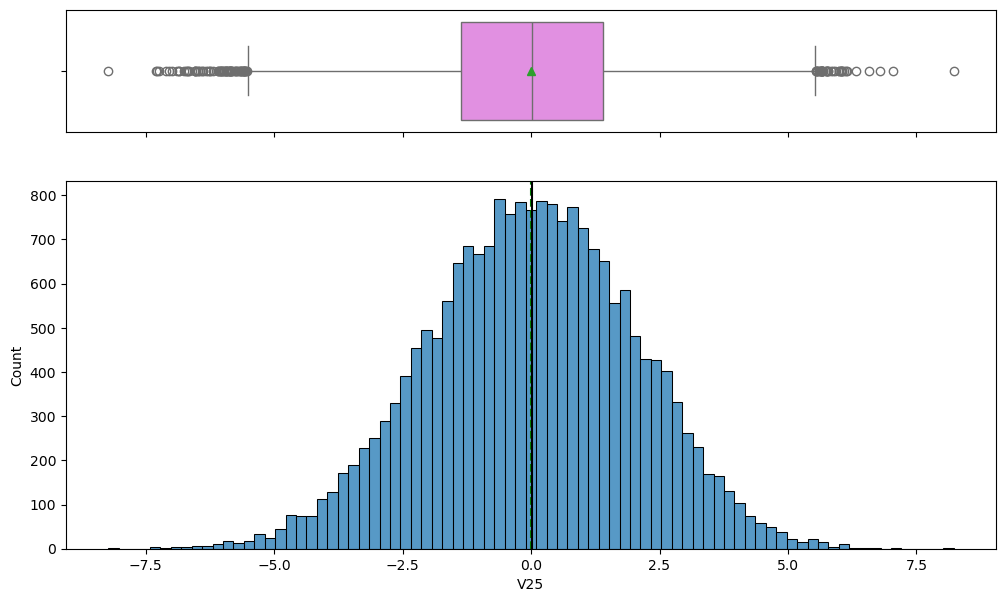

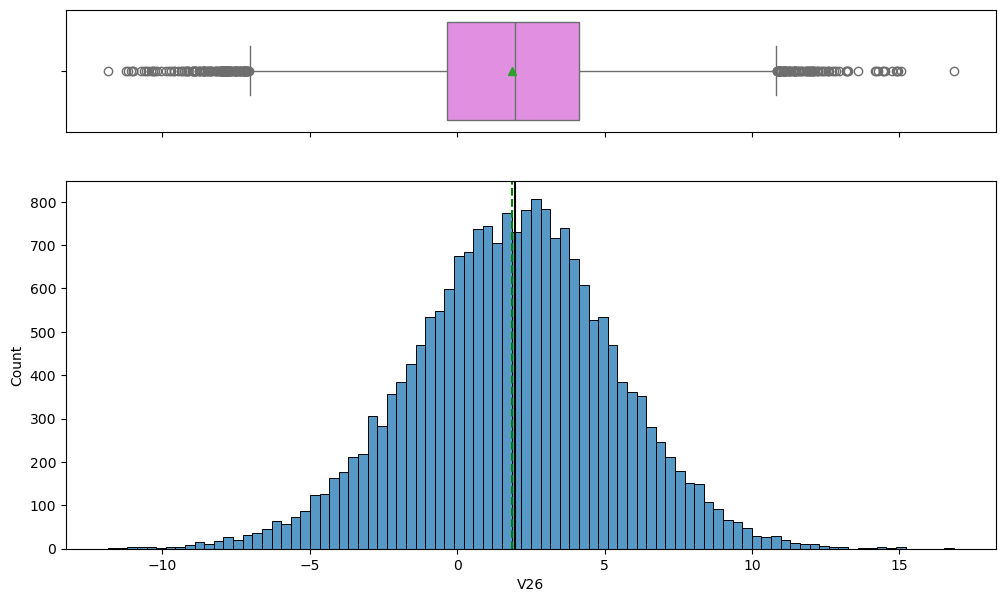

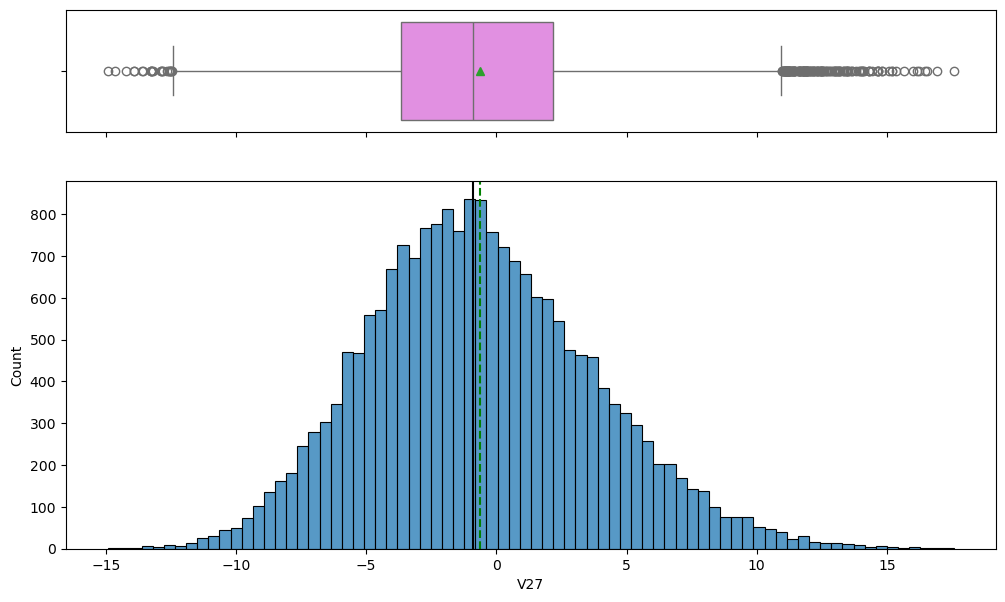

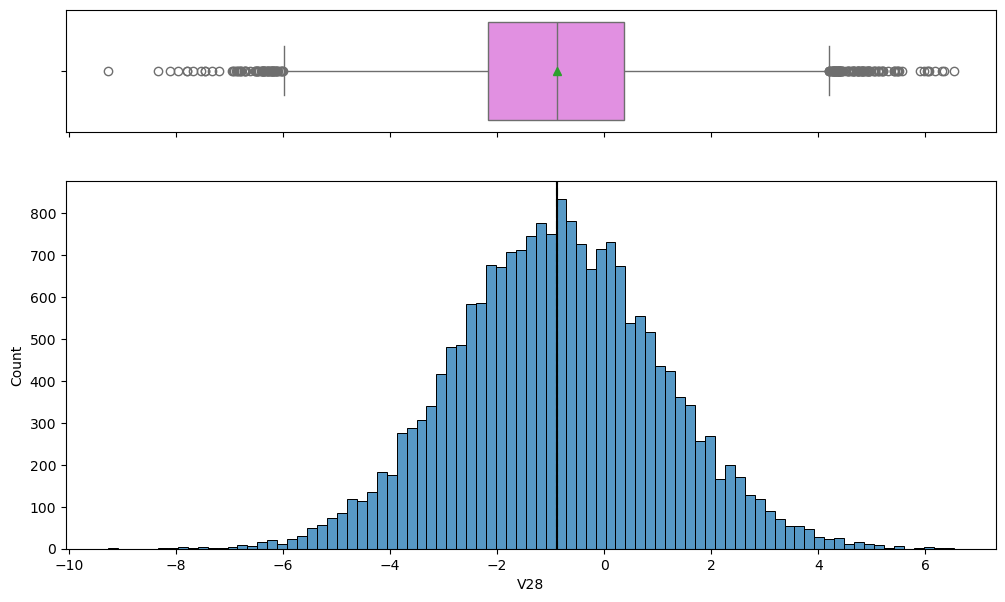

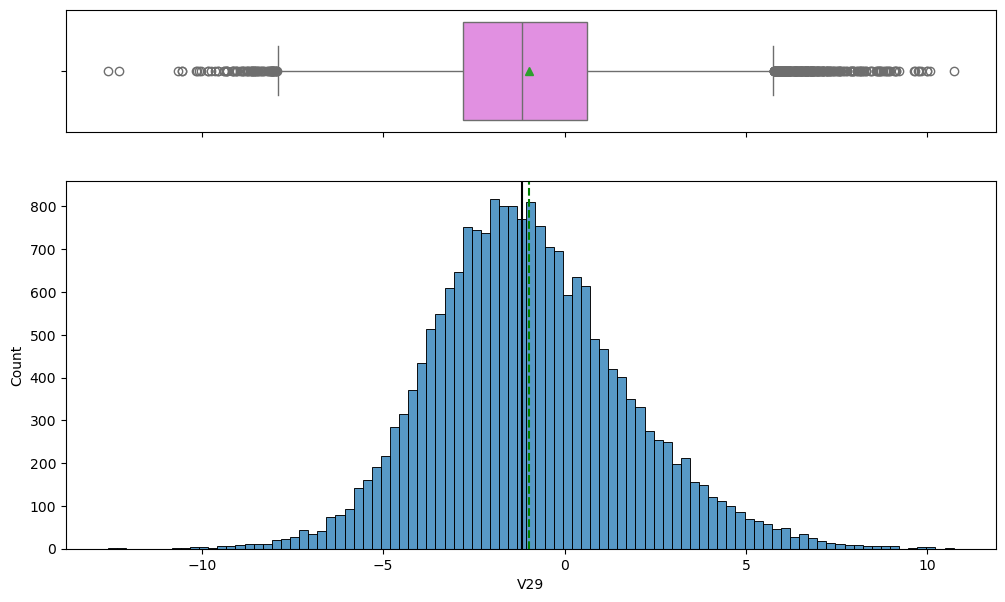

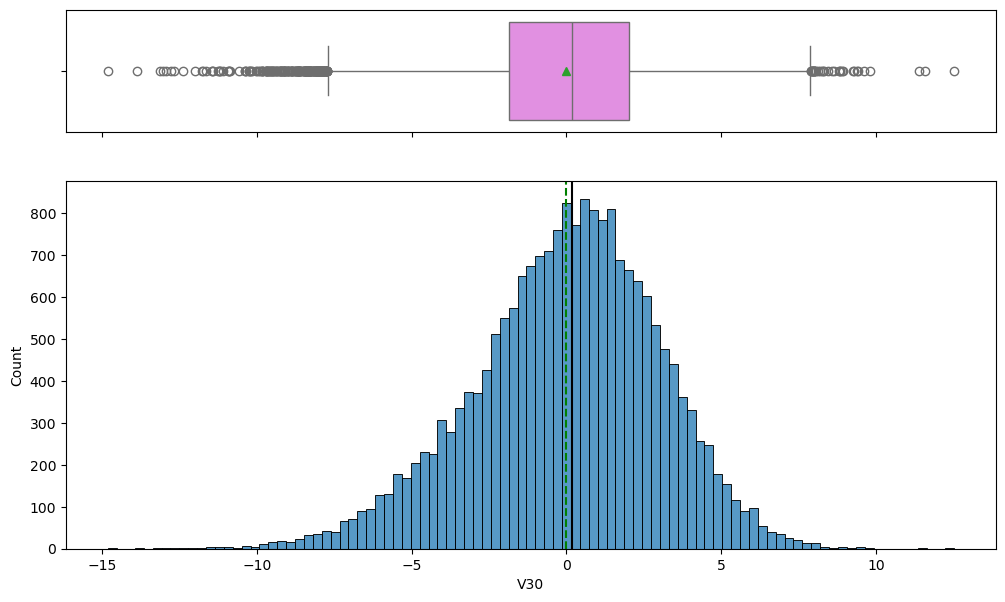

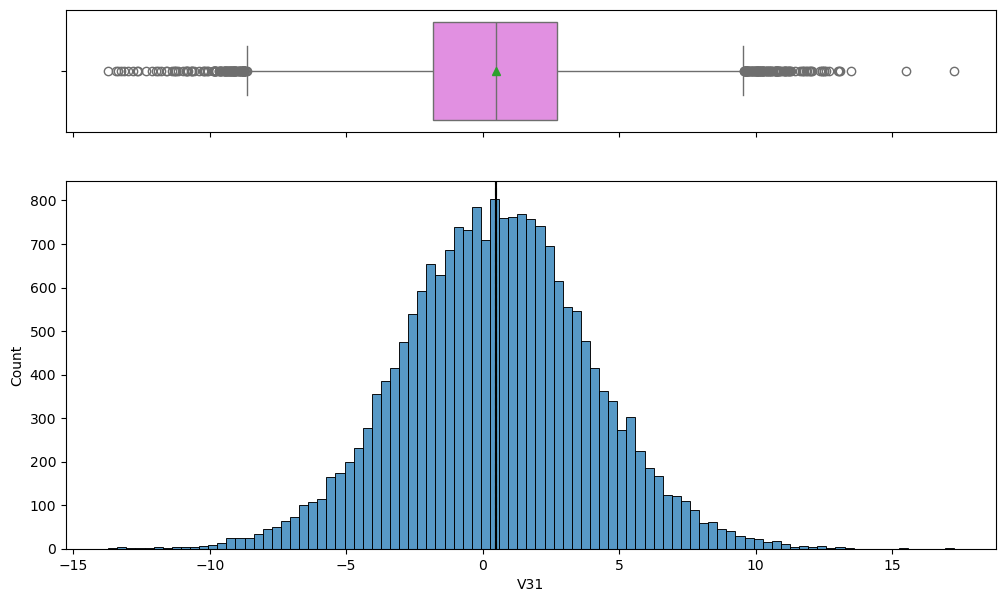

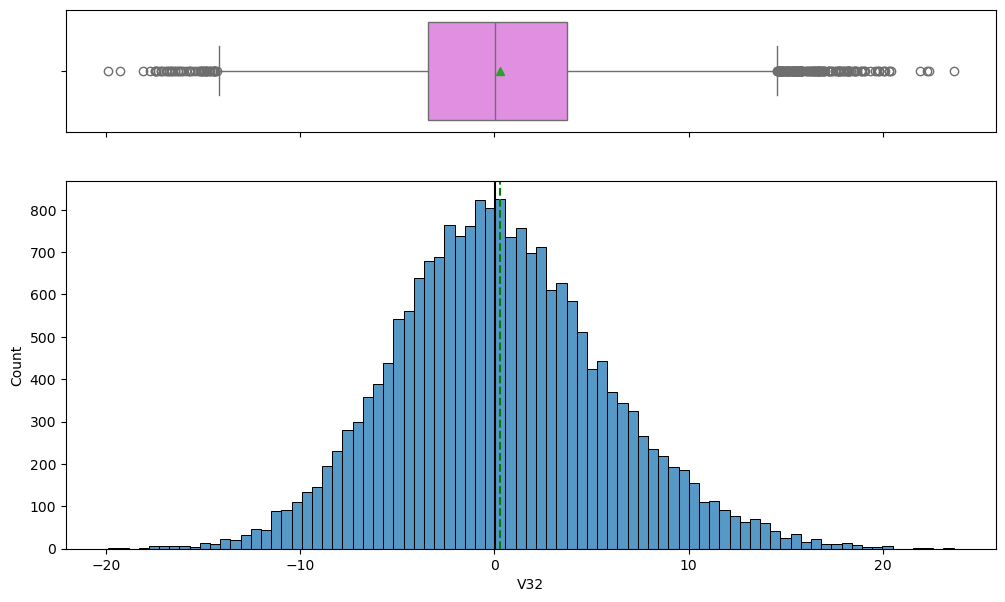

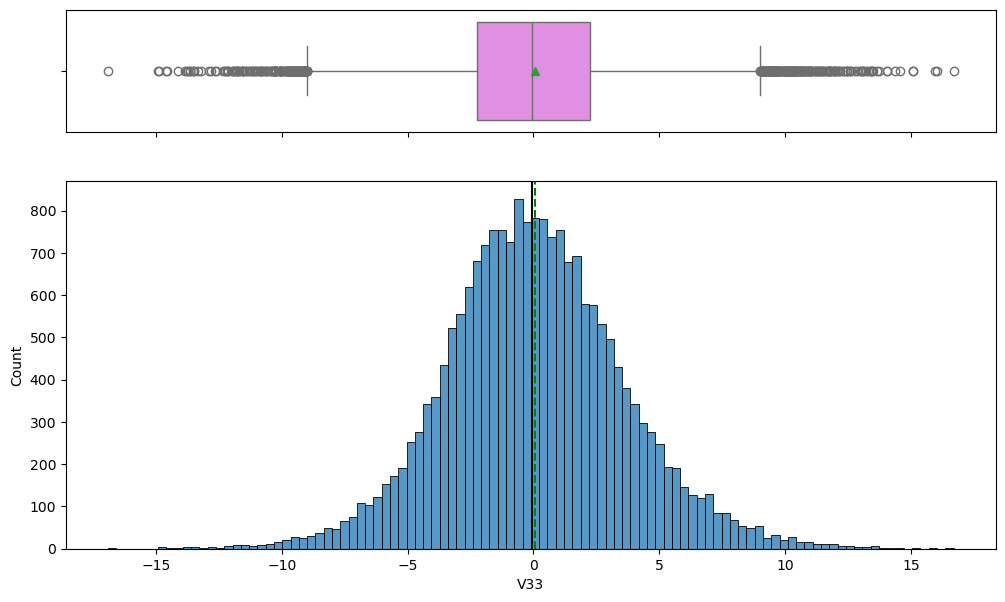

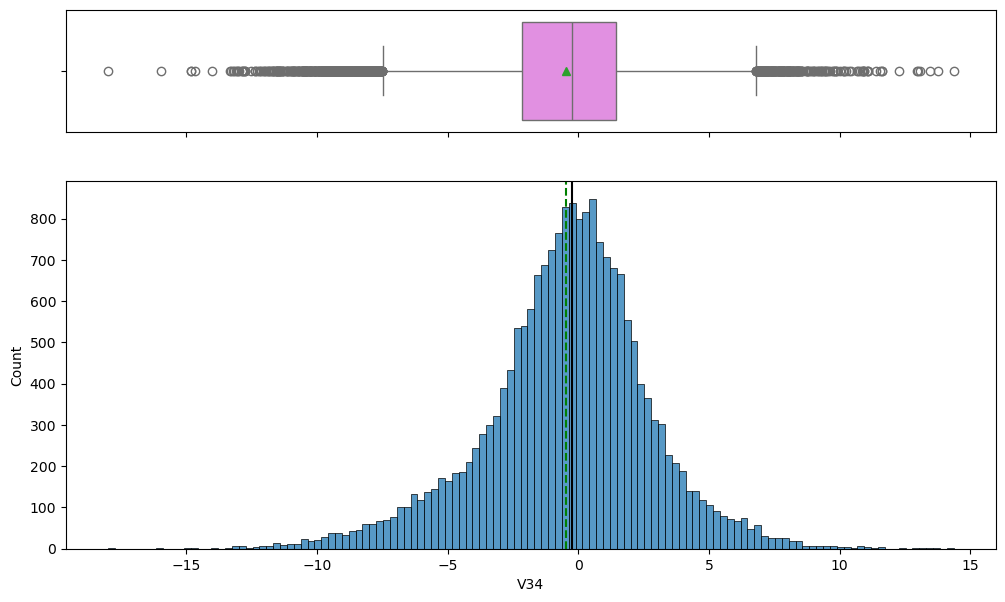

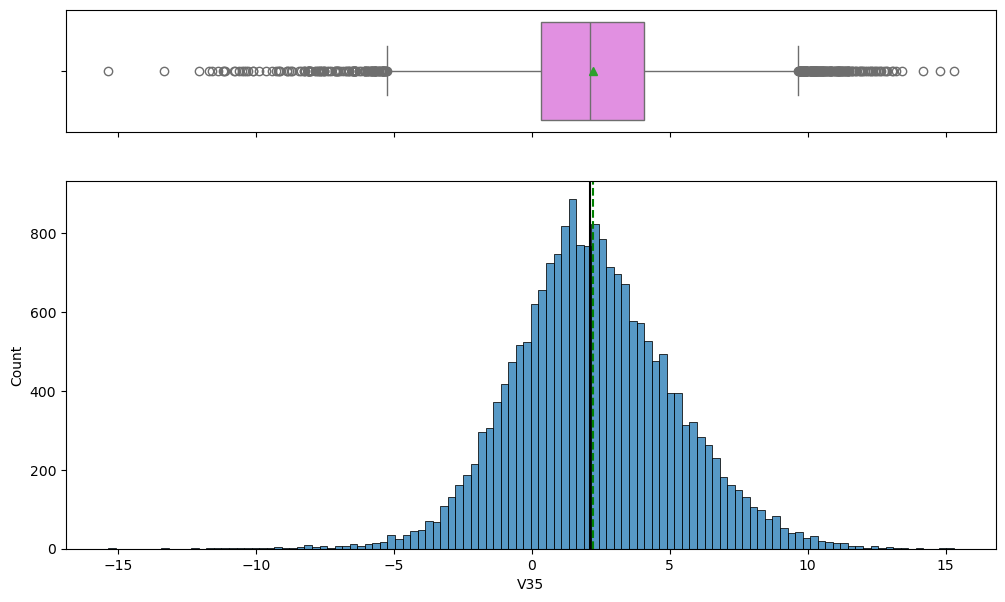

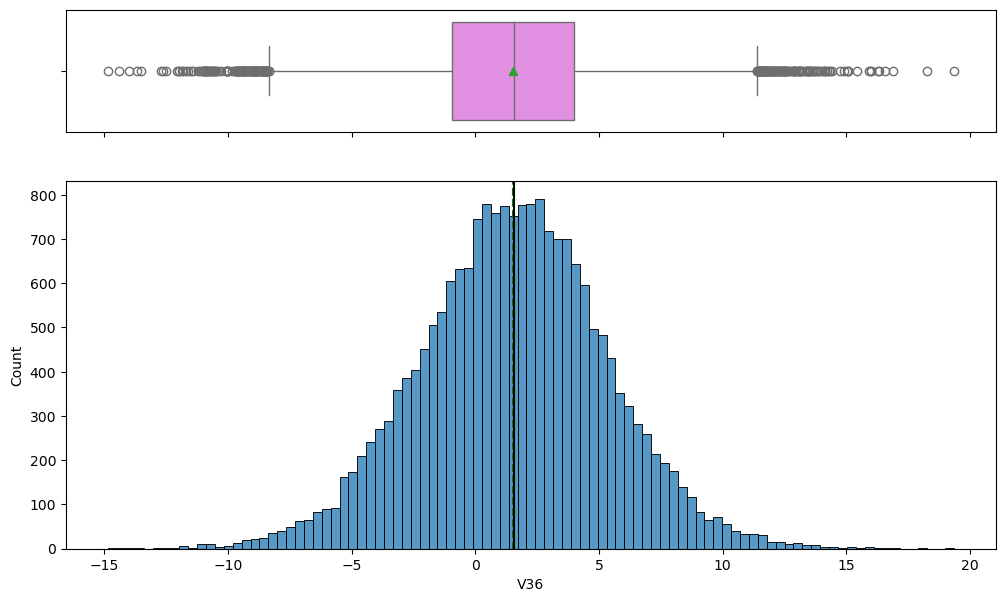

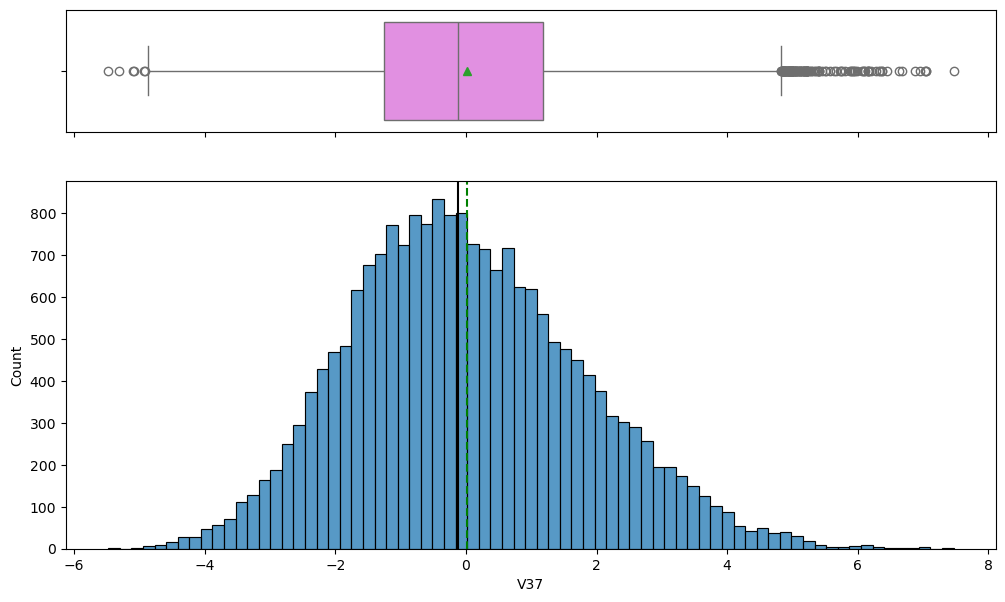

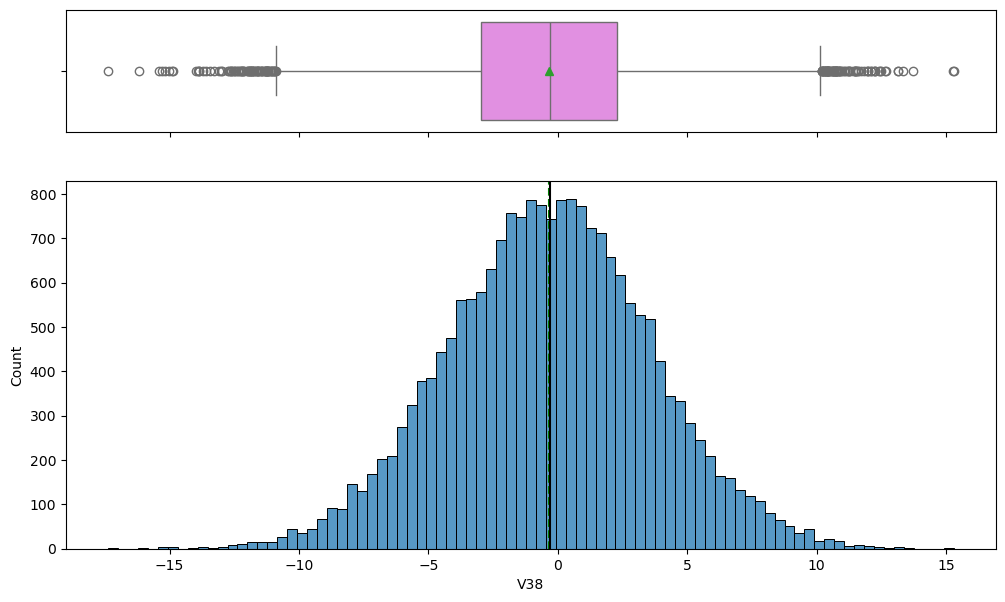

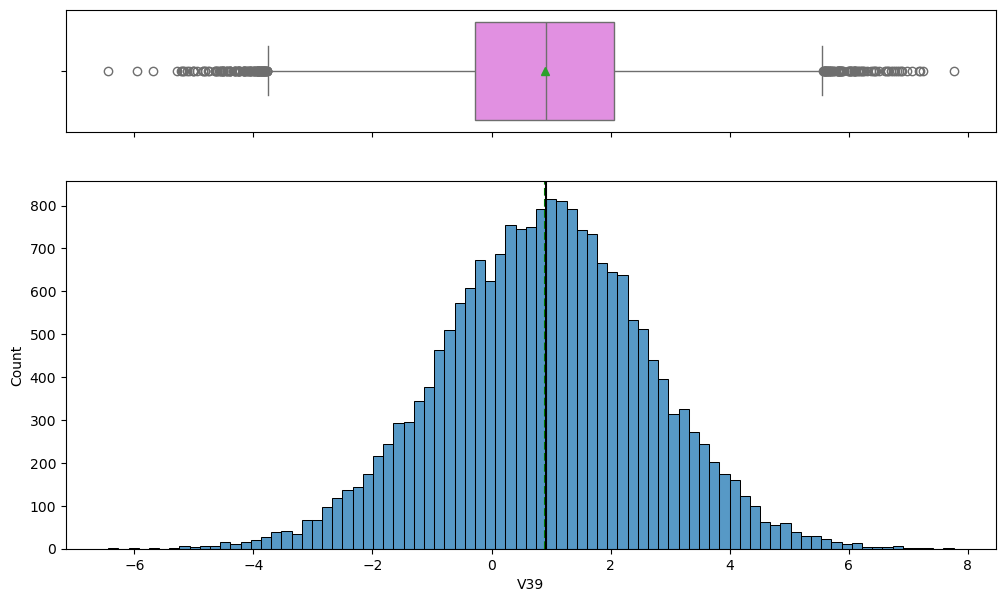

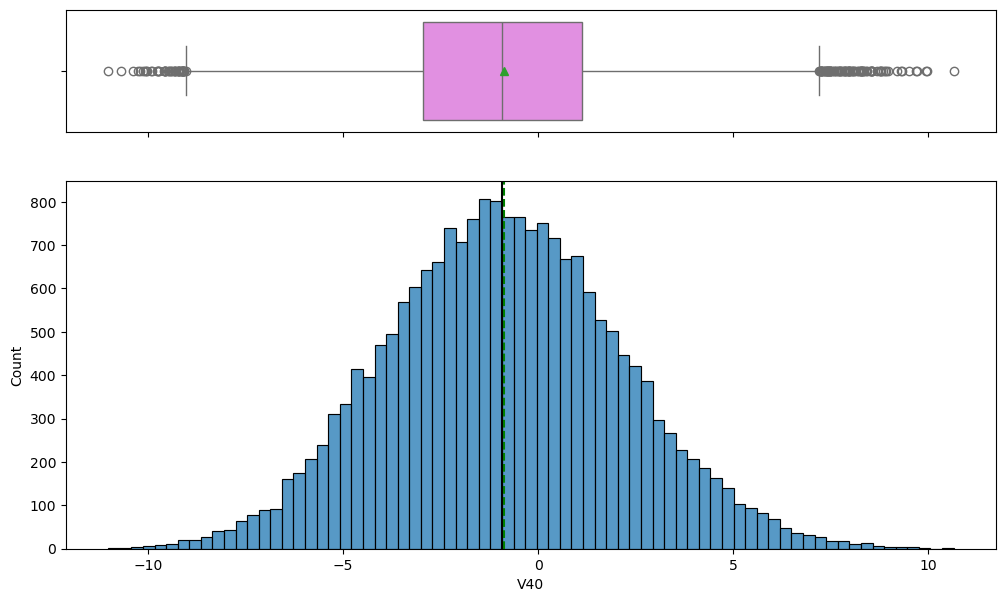

In [1419]:
for i in list(range(1, 41)):
    histogram_boxplot(Data, f"V{i}")

## Bivariate Analysis

* Bivariate analysis isn't very helpful here because the inputs are all numerical inputs from 40 different sensors.
* Also, there is no categorical data to separate the data into different buckets.

# **Data Preprocessing**

In [1420]:
# Dropping the 36 rows with null values in V1 / V2 instead of imputing data
Data.dropna(inplace=True)
Data.shape

(19964, 41)

In [1421]:
# Separating Independent and Dependent Columns
X = Data.drop(['Target'],axis=1)
Y = Data['Target']

In [1422]:
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,1.667098,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,0.024883,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-1.600395,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,4.948770,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,2.044184,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338


In [1423]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: Target, dtype: int64

In [1424]:
#Calculating the total number of nan values for each columns.
X.isnull().sum()

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64

In [1425]:
# Scaling the training data
scaler = StandardScaler()
subset_scaled = scaler.fit_transform(X)

# create a dataframe of the scaled data
Xt = pd.DataFrame(subset_scaled, columns=X.columns)


In [1426]:
Xt.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19964.0,2.847296e-17,1.000025,-3.371605,-0.716495,-0.137987,0.613645,4.579850
V2,19964.0,-7.118240e-18,1.000025,-4.049890,-0.660492,0.009610,0.667758,4.014440
V3,19964.0,-4.199762e-17,1.000025,-3.891168,-0.671884,-0.067736,0.614785,4.307569
V4,19964.0,-1.423648e-18,1.000025,-4.370235,-0.659398,-0.015324,0.644899,3.880639
V5,19964.0,-5.872548e-18,1.000025,-4.060831,-0.704101,-0.022962,0.662308,3.890050
V6,19964.0,3.559120e-19,1.000025,-4.522764,-0.662592,-0.002640,0.674081,3.905284
V7,19964.0,-5.267498e-17,1.000025,-4.013321,-0.653979,-0.021654,0.625909,5.043218
V8,19964.0,-6.050504e-18,1.000025,-4.583146,-0.636715,0.047960,0.689993,3.709147
V9,19964.0,8.541888e-18,1.000025,-3.970299,-0.684233,-0.023284,0.659959,3.773363
V10,19964.0,-1.245692e-17,1.000025,-4.486800,-0.638294,0.052283,0.679375,3.702347


In [1427]:
X = Xt.copy()

In [1428]:
# Splitting the dataset into the Training and Test set.
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42,stratify = Y)

In [1429]:
# Splitting the Train dataset into the Training and Validation set.
X_train, X_valid, y_train, y_valid = train_test_split(X_train,y_train, test_size = 0.2, random_state = 42,stratify = y_train)

In [1430]:
#Printing the shapes.
print(X_train.shape,y_train.shape)
print(X_valid.shape,y_valid.shape)
print(X_test.shape,y_test.shape)

(12776, 40) (12776,)
(3195, 40) (3195,)
(3993, 40) (3993,)


## Utility Functions

In [1431]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},
        index=[0],
    )

    return df_perf

# **Model Building**

## Model Evaluation Criterion

**A model can make wrong predictions in the following ways:**
* Predicting a generator is going to fail when in fact it is not.  This results in the cost of an unnecessary inspection.
* Predicting a generator is not going to fail when in fact it fails.  This results in the cost of a generator replacement.

**Which case is more important?**

Because the cost of a generator replacement is much more costly than an unnecessary inspection, it is more important to predict as many failures as possible even if it results in extra inspections.

**How to reduce this loss i.e need to reduce False Negatives as well as False Positives?**

Since false negatives are important for us to minimize, the company would want the Recall score evaluation metric to be maximized.  Hence, the focus should be on increasing the recall score.  Accuracy would be a secondary metric to optimize on.


In [1432]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train)

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0588430300016576), 1: np.float64(17.994366197183098)}

In [1433]:
# defining the batch size and # epochs upfront as we'll be using the same values for all models
epochs = 25
batch_size = 64

In [1434]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [1435]:
#Initializing the neural network
model0 = Sequential()
model0.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model0.add(Dense(1,activation="sigmoid"))
optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used
model0.compile(loss='binary_crossentropy', optimizer=optimizer)
model0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841 (3.29 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

In [1436]:
#Fit model 0
start = time.time()
history = model0.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.3538 - val_loss: 0.2336
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - loss: 0.2133 - val_loss: 0.1868
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - loss: 0.1845 - val_loss: 0.1650
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 0.1689 - val_loss: 0.1508
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - loss: 0.1579 - val_loss: 0.1401
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - loss: 0.1492 - val_loss: 0.1316
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step - loss: 0.1420 - val_loss: 0.1244
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - loss: 0.1358 - val_loss: 0.1184
Epoch 9/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - loss: 0.1305 - val_loss: 0.1133
Epoch 10/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - loss: 0.1258 - val_loss: 0.1088
Epoch 11/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - loss: 0.1218 - val_loss: 0.1048
Epoch 12/25
200/200 ━━━━━━━━━━

400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 282us/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step


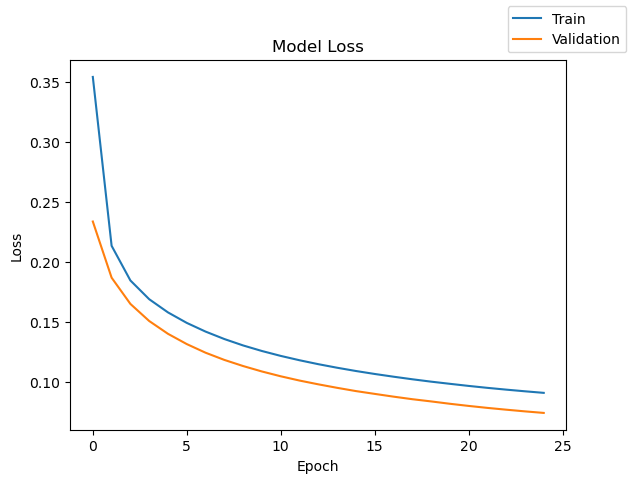

In [1437]:
plot(history,'loss')
model_0_train_perf = model_performance_classification(model0, X_train, y_train)
model_0_valid_perf = model_performance_classification(model0, X_valid, y_valid)


In [1438]:
model_0_train_perf

,Accuracy,Recall,Precision,F1 Score
0,0.97871,0.97871,0.978498,0.976629


In [1439]:
model_0_valid_perf

,Accuracy,Recall,Precision,F1 Score
0,0.980908,0.980908,0.981113,0.979104


* Model0 is the base model.  Recall and accuracy are about 98%.

# **Model Performance Improvement**

## Model 1

In [1440]:
#Clean
tf.keras.backend.clear_session()

#define a new model with an additional hidden layer
model1 = Sequential()
model1.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model1.add(Dense(10,activation="relu"))
model1.add(Dense(1,activation="sigmoid"))

optimizer = tf.keras.optimizers.SGD() 
model1.compile(loss='binary_crossentropy', optimizer=optimizer)

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,041 (4.07 KB)

 Trainable params: 1,041 (4.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3810 - val_loss: 0.2389
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - loss: 0.2112 - val_loss: 0.1866
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step - loss: 0.1770 - val_loss: 0.1603
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - loss: 0.1565 - val_loss: 0.1413
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - loss: 0.1415 - val_loss: 0.1270
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - loss: 0.1302 - val_loss: 0.1162
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - loss: 0.1216 - val_loss: 0.1080
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - loss: 0.1149 - val_loss: 0.1016
Epoch 9/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - loss: 0.1095 - val_loss: 0.0964
Epoch 10/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 0.1051 - val_loss: 0.0921
Epoch 11/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - loss: 0.1014 - val_loss: 0.0886
Epoch 12/25
200/200 ━━━━━━━━━━━━

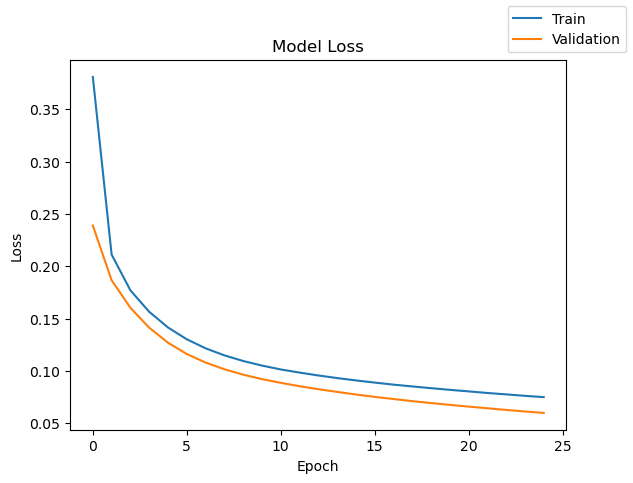

In [1441]:
#Fit model 1

start = time.time()
history = model1.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs)
end=time.time()

plot(history,'loss')

In [1442]:
model_1_train_perf = model_performance_classification(model1, X_train, y_train)
model_1_valid_perf = model_performance_classification(model1, X_valid, y_valid)

400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step


In [1443]:
model_1_train_perf

,Accuracy,Recall,Precision,F1 Score
0,0.98325,0.98325,0.983048,0.982081


In [1444]:
model_1_valid_perf

,Accuracy,Recall,Precision,F1 Score
0,0.986541,0.986541,0.986624,0.985711


* Model1 adds a hidden layer to Model0, resulting is slightly higher recall and accuracy.  The model is improved slightly by adding a hidden layer.

## Model 2

In [1445]:
model_1_valid_perf

,Accuracy,Recall,Precision,F1 Score
0,0.986541,0.986541,0.986624,0.985711


In [1446]:
#Clean
tf.keras.backend.clear_session()

#define a new model with a different optimizer
model2 = Sequential()
model2.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model2.add(Dense(10,activation="relu"))
model2.add(Dense(1,activation="sigmoid"))

optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model2.compile(loss='binary_crossentropy', optimizer=optimizer)

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,041 (4.07 KB)

 Trainable params: 1,041 (4.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - loss: 0.2605 - val_loss: 0.1483
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - loss: 0.1332 - val_loss: 0.1064
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - loss: 0.1093 - val_loss: 0.0876
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step - loss: 0.0957 - val_loss: 0.0737
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step - loss: 0.0856 - val_loss: 0.0631
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - loss: 0.0766 - val_loss: 0.0573
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - loss: 0.0708 - val_loss: 0.0505
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - loss: 0.0658 - val_loss: 0.0473
Epoch 9/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - loss: 0.0633 - val_loss: 0.0425
Epoch 10/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - loss: 0.0608 - val_loss: 0.0416
Epoch 11/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - loss: 0.0585 - val_loss: 0.0387
Epoch 12/25
200/200 ━━━━━━━━━━

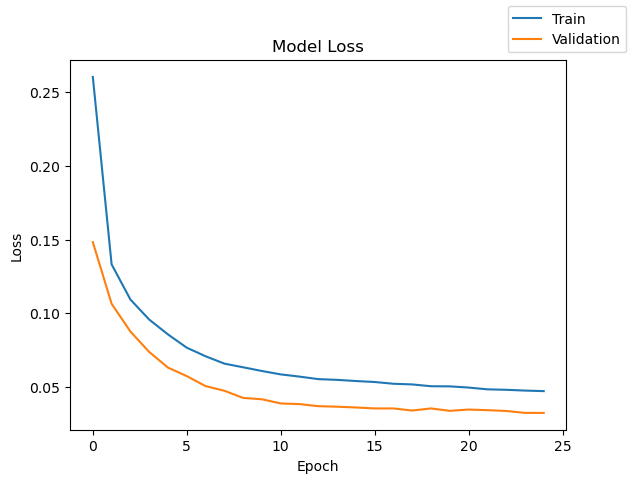

In [1447]:
#Fit model 2

start = time.time()
history = model2.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs)
end=time.time()

plot(history,'loss')
model_2_train_perf = model_performance_classification(model2, X_train, y_train)
model_2_valid_perf = model_performance_classification(model2, X_valid, y_valid)

In [1448]:
model_2_train_perf

,Accuracy,Recall,Precision,F1 Score
0,0.990999,0.990999,0.990921,0.990707


In [1449]:
model_2_valid_perf

,Accuracy,Recall,Precision,F1 Score
0,0.99374,0.99374,0.99374,0.993583


* Model2 switches the SGD optimizer of Model1 to an Adam optimizer.  The model slightly improves again in both recall and accuracy performance.

## Model 3

In [1450]:
#Clean
tf.keras.backend.clear_session()

#define a new model with more hidden layers
model3 = Sequential()
model3.add(Dense(20,activation="relu",input_dim=X_train.shape[1]))
model3.add(Dense(10,activation="relu"))
model3.add(Dense(6,activation="relu"))
model3.add(Dense(1,activation="sigmoid"))

optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model3.compile(loss='binary_crossentropy', optimizer=optimizer)

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,103 (4.31 KB)

 Trainable params: 1,103 (4.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 815us/step - loss: 0.3729 - val_loss: 0.1382
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - loss: 0.1191 - val_loss: 0.0800
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - loss: 0.0859 - val_loss: 0.0616
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - loss: 0.0731 - val_loss: 0.0510
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - loss: 0.0660 - val_loss: 0.0459
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - loss: 0.0616 - val_loss: 0.0424
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - loss: 0.0573 - val_loss: 0.0414
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - loss: 0.0545 - val_loss: 0.0361
Epoch 9/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 0.0516 - val_loss: 0.0346
Epoch 10/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - loss: 0.0500 - val_loss: 0.0339
Epoch 11/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - loss: 0.0484 - val_loss: 0.0327
Epoch 12/25
200/200 ━━━━━━━━━━

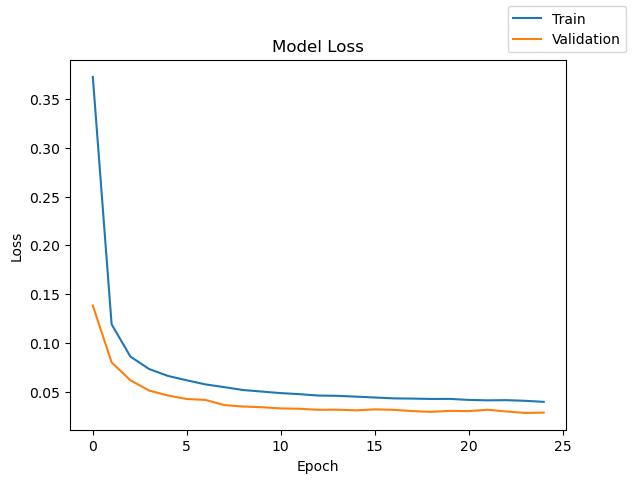

In [1451]:
#Fit model 3

start = time.time()
history = model3.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs)
end=time.time()

plot(history,'loss')
model_3_train_perf = model_performance_classification(model3, X_train, y_train)
model_3_valid_perf = model_performance_classification(model3, X_valid, y_valid)

In [1452]:
model_3_train_perf

,Accuracy,Recall,Precision,F1 Score
0,0.992642,0.992642,0.992577,0.992462


In [1453]:
model_3_valid_perf

,Accuracy,Recall,Precision,F1 Score
0,0.994679,0.994679,0.994633,0.994599


* Model3 adds a hidden layer to the Model2.  The model doesn't get better or worse as a result.

## Model 4

In [1454]:
#Clean
tf.keras.backend.clear_session()

#define a new model with dropout
model4 = Sequential()
model4.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model4.add(Dropout(0.4))
model4.add(Dense(7,activation="relu"))
model4.add(Dropout(0.2))
model4.add(Dense(1,activation="sigmoid"))

optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model4.compile(loss='binary_crossentropy', optimizer=optimizer)

model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 802us/step - loss: 0.5271 - val_loss: 0.2548
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - loss: 0.2632 - val_loss: 0.1388
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 0.2038 - val_loss: 0.1145
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - loss: 0.1801 - val_loss: 0.1028
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - loss: 0.1614 - val_loss: 0.0926
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 0.1536 - val_loss: 0.0872
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - loss: 0.1451 - val_loss: 0.0794
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - loss: 0.1397 - val_loss: 0.0741
Epoch 9/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 0.1317 - val_loss: 0.0683
Epoch 10/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - loss: 0.1296 - val_loss: 0.0643
Epoch 11/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 0.1273 - val_loss: 0.0635
Epoch 12/25
200/200 ━━━━━━━━━━

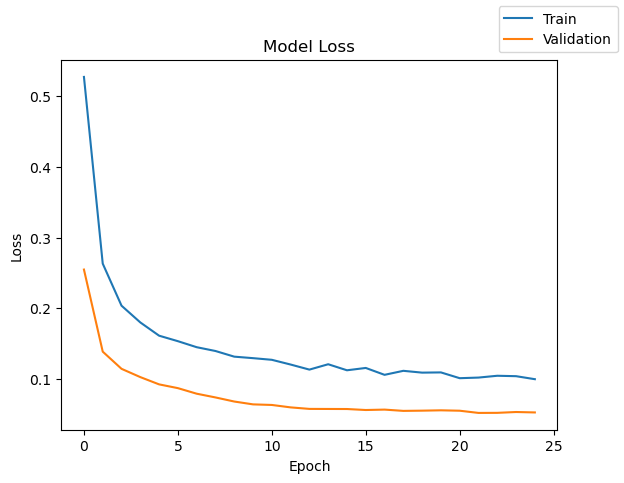

In [1455]:
#Fit model 4

start = time.time()
history = model4.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs)
end=time.time()

plot(history,'loss')
model_4_train_perf = model_performance_classification(model4, X_train, y_train)
model_4_valid_perf = model_performance_classification(model4, X_valid, y_valid)

In [1456]:
model_4_train_perf

,Accuracy,Recall,Precision,F1 Score
0,0.983641,0.983641,0.983626,0.982434


In [1457]:
model_4_valid_perf

,Accuracy,Recall,Precision,F1 Score
0,0.986541,0.986541,0.98653,0.985757


* Model4 adds dropout layers.  The model gets worse as a result in both recall and accuracy performance.

## Model 5

In [1458]:
#Clean
tf.keras.backend.clear_session()

#define a new model with batch normalization
model5 = Sequential()
model5.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model5.add(BatchNormalization())
model5.add(Dense(7,activation="relu"))
model5.add(BatchNormalization())
model5.add(Dense(1,activation="sigmoid"))

optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model5.compile(loss='binary_crossentropy', optimizer=optimizer)

model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7)              │            28 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771 (3.01 KB)

 Trainable params: 729 (2.85 KB)

 Non-trainable params: 42 (168.00 B)

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 964us/step - loss: 0.5569 - val_loss: 0.3301
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - loss: 0.2614 - val_loss: 0.1318
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step - loss: 0.1282 - val_loss: 0.0761
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 0.0909 - val_loss: 0.0584
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 0.0762 - val_loss: 0.0498
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 0.0674 - val_loss: 0.0452
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step - loss: 0.0629 - val_loss: 0.0400
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - loss: 0.0591 - val_loss: 0.0401
Epoch 9/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 0.0566 - val_loss: 0.0397
Epoch 10/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - loss: 0.0557 - val_loss: 0.0359
Epoch 11/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - loss: 0.0536 - val_loss: 0.0359
Epoch 12/25
200/200 ━━━━━━━━━━

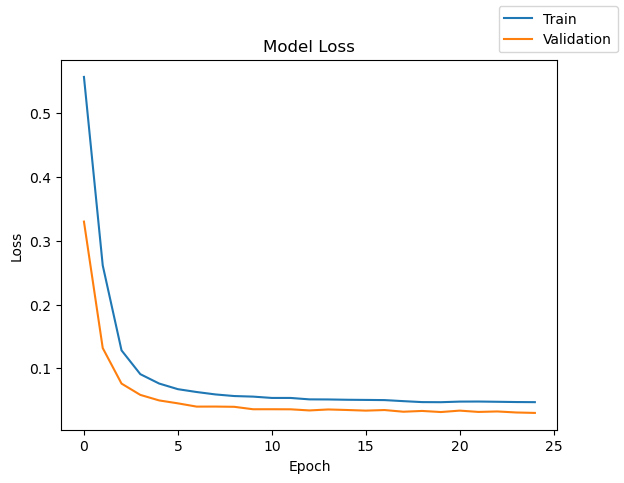

In [1459]:
#Fit model 5

start = time.time()
history = model5.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs)
end=time.time()

plot(history,'loss')
model_5_train_perf = model_performance_classification(model5, X_train, y_train)
model_5_valid_perf = model_performance_classification(model5, X_valid, y_valid)

In [1460]:
model_5_train_perf

,Accuracy,Recall,Precision,F1 Score
0,0.991468,0.991468,0.991423,0.991192


In [1461]:
model_5_valid_perf

,Accuracy,Recall,Precision,F1 Score
0,0.994992,0.994992,0.994964,0.99491


* Model5 removes dropout layers and adds batch normalization layers.  The model improves as a result in both recall and accuracy performance.

## Model 6

- Adding both batchnormalization and dropout.

In [1462]:
#Clean
tf.keras.backend.clear_session()

#define a new model with batch normalization, dropout, and class weights
model6 = Sequential()
model6.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model6.add(BatchNormalization())
model6.add(Dropout(0.4))
model6.add(Dense(7,activation="relu"))
model6.add(BatchNormalization())
model6.add(Dropout(0.2))
model6.add(Dense(1,activation="sigmoid"))

optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model6.compile(loss='binary_crossentropy', optimizer=optimizer)

model6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7)              │            28 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771 (3.01 KB)

 Trainable params: 729 (2.85 KB)

 Non-trainable params: 42 (168.00 B)

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 985us/step - loss: 1.3467 - val_loss: 0.5148
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - loss: 1.0232 - val_loss: 0.3812
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - loss: 0.8970 - val_loss: 0.3335
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step - loss: 0.8740 - val_loss: 0.3077
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - loss: 0.8105 - val_loss: 0.2809
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - loss: 0.8109 - val_loss: 0.2833
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - loss: 0.7633 - val_loss: 0.2691
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - loss: 0.7514 - val_loss: 0.2543
Epoch 9/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - loss: 0.7044 - val_loss: 0.2241
Epoch 10/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - loss: 0.7237 - val_loss: 0.2295
Epoch 11/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - loss: 0.6889 - val_loss: 0.2117
Epoch 12/25
200/200 ━━━━━━━━━━

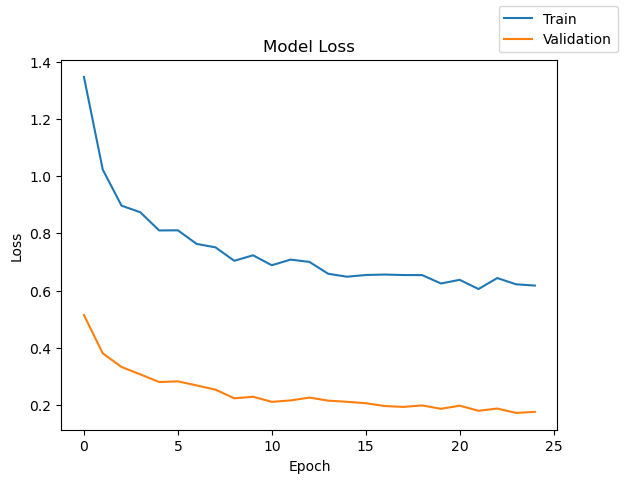

In [1463]:
#Fit model 6

start = time.time()
history = model6.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

plot(history,'loss')
model_6_train_perf = model_performance_classification(model6, X_train, y_train)
model_6_valid_perf = model_performance_classification(model6, X_valid, y_valid)

In [1464]:
model_6_train_perf

,Accuracy,Recall,Precision,F1 Score
0,0.963291,0.963291,0.971831,0.966204


In [1465]:
model_6_valid_perf

,Accuracy,Recall,Precision,F1 Score
0,0.968075,0.968075,0.976053,0.970624


* Model6 features dropout layers, batch normalization layers, and class weights.  The model gets worse as a result in both recall and accuracy performance.

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [1466]:
print('Model0 Training:')
model_0_train_perf

Model0 Training:


,Accuracy,Recall,Precision,F1 Score
0,0.97871,0.97871,0.978498,0.976629


In [1467]:
print('Model0 Validation:')
model_0_valid_perf

Model0 Validation:


,Accuracy,Recall,Precision,F1 Score
0,0.980908,0.980908,0.981113,0.979104


In [1468]:
print('Model1 Training:')
model_1_train_perf

Model1 Training:


,Accuracy,Recall,Precision,F1 Score
0,0.98325,0.98325,0.983048,0.982081


In [1469]:
print('Model1 Validation:')
model_1_valid_perf

Model1 Validation:


,Accuracy,Recall,Precision,F1 Score
0,0.986541,0.986541,0.986624,0.985711


In [1470]:
print('Model2 Training:')
model_2_train_perf

Model2 Training:


,Accuracy,Recall,Precision,F1 Score
0,0.990999,0.990999,0.990921,0.990707


In [1471]:
print('Model2 Validation:')
model_2_valid_perf

Model2 Validation:


,Accuracy,Recall,Precision,F1 Score
0,0.99374,0.99374,0.99374,0.993583


In [1472]:
print('Model3 Training:')
model_3_train_perf

Model3 Training:


,Accuracy,Recall,Precision,F1 Score
0,0.992642,0.992642,0.992577,0.992462


In [1473]:
print('Model3 Validation:')
model_3_valid_perf

Model3 Validation:


,Accuracy,Recall,Precision,F1 Score
0,0.994679,0.994679,0.994633,0.994599


In [1474]:
print('Model4 Training:')
model_4_train_perf

Model4 Training:


,Accuracy,Recall,Precision,F1 Score
0,0.983641,0.983641,0.983626,0.982434


In [1475]:
print('Model4 Validation:')
model_4_valid_perf

Model4 Validation:


,Accuracy,Recall,Precision,F1 Score
0,0.986541,0.986541,0.98653,0.985757


In [1476]:
print('Model5 Training:')
model_5_train_perf

Model5 Training:


,Accuracy,Recall,Precision,F1 Score
0,0.991468,0.991468,0.991423,0.991192


In [1477]:
print('Model5 Validation:')
model_5_valid_perf

Model5 Validation:


,Accuracy,Recall,Precision,F1 Score
0,0.994992,0.994992,0.994964,0.99491


In [1478]:
print('Model6 Training:')
model_6_train_perf

Model6 Training:


,Accuracy,Recall,Precision,F1 Score
0,0.963291,0.963291,0.971831,0.966204


In [1479]:
print('Model6 Validation:')
model_6_valid_perf

Model6 Validation:


,Accuracy,Recall,Precision,F1 Score
0,0.968075,0.968075,0.976053,0.970624


* Model3 is the best performing model with recall and accuracy metrics.

Now, let's check the performance of the final model on the test set.

In [1480]:
X_final = DataTest.drop(['Target'],axis=1)
Y_final = DataTest['Target']

y_final_pred = model3.predict(X_final)

model_3_final_perf = model_performance_classification(model3, X_final, Y_final)
model_3_final_perf


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step


,Accuracy,Recall,Precision,F1 Score
0,0.9836,0.9836,0.98307,0.983196


* The final scores with the data in Test.csv are above.  It is slightly worse performance than on the training and validation data, but only by a small margin.

# **Actionable Insights and Recommendations**

Write down some insights and business recommendations based on your observations.

* The Neural network is effective at predicting generator failures by analyzing sensor data alone.
* Data from more sensors, if available, might improve the model.
* Categorical data might also help.  Things such as supplier, location, etc.